<a href="https://colab.research.google.com/github/muhammad-siddique-research/financial-risk-ai/blob/main/04_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Financial Risk Prediction Using Econometric and Machine Learning Approaches

## Feature Engineering

This notebook prepares financial indicators for predictive modeling by selecting relevant variables, transforming features, and creating machine learning-ready datasets.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Feature engineering environment initialized successfully")

Feature engineering environment initialized successfully


In [ ]:
url = "https://raw.githubusercontent.com/muhammad-siddique-research/financial-risk-ai/main/data/processed/financial_data_cleaned.csv"

df = pd.read_csv(url)

print("Cleaned dataset loaded successfully")

df.head()

Cleaned dataset loaded successfully


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [ ]:
df.columns.tolist()

['Bankrupt?',
 ' ROA(C) before interest and depreciation before interest',
 ' ROA(A) before interest and % after tax',
 ' ROA(B) before interest and depreciation after tax',
 ' Operating Gross Margin',
 ' Realized Sales Gross Margin',
 ' Operating Profit Rate',
 ' Pre-tax net Interest Rate',
 ' After-tax net Interest Rate',
 ' Non-industry income and expenditure/revenue',
 ' Continuous interest rate (after tax)',
 ' Operating Expense Rate',
 ' Research and development expense rate',
 ' Cash flow rate',
 ' Interest-bearing debt interest rate',
 ' Tax rate (A)',
 ' Net Value Per Share (B)',
 ' Net Value Per Share (A)',
 ' Net Value Per Share (C)',
 ' Persistent EPS in the Last Four Seasons',
 ' Cash Flow Per Share',
 ' Revenue Per Share (Yuan ¥)',
 ' Operating Profit Per Share (Yuan ¥)',
 ' Per Share Net profit before tax (Yuan ¥)',
 ' Realized Sales Gross Profit Growth Rate',
 ' Operating Profit Growth Rate',
 ' After-tax Net Profit Growth Rate',
 ' Regular Net Profit Growth Rate',
 ' C

In [ ]:
# Remove hidden spaces from column names

df.columns = df.columns.str.strip()

print(df.columns[0])

Bankrupt?


In [ ]:
# Separate target variable and predictors

target = "Bankrupt?"

X = df.drop(target, axis=1)

y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (6819, 95)
Target shape: (6819,)


In [ ]:
df.columns.tolist()

['Bankrupt?',
 'ROA(C) before interest and depreciation before interest',
 'ROA(A) before interest and % after tax',
 'ROA(B) before interest and depreciation after tax',
 'Operating Gross Margin',
 'Realized Sales Gross Margin',
 'Operating Profit Rate',
 'Pre-tax net Interest Rate',
 'After-tax net Interest Rate',
 'Non-industry income and expenditure/revenue',
 'Continuous interest rate (after tax)',
 'Operating Expense Rate',
 'Research and development expense rate',
 'Cash flow rate',
 'Interest-bearing debt interest rate',
 'Tax rate (A)',
 'Net Value Per Share (B)',
 'Net Value Per Share (A)',
 'Net Value Per Share (C)',
 'Persistent EPS in the Last Four Seasons',
 'Cash Flow Per Share',
 'Revenue Per Share (Yuan ¥)',
 'Operating Profit Per Share (Yuan ¥)',
 'Per Share Net profit before tax (Yuan ¥)',
 'Realized Sales Gross Profit Growth Rate',
 'Operating Profit Growth Rate',
 'After-tax Net Profit Growth Rate',
 'Regular Net Profit Growth Rate',
 'Continuous Net Profit Growth 

In [ ]:
# Separate target variable and predictors

X = df.drop("Bankrupt?", axis=1)

y = df["Bankrupt?"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (6819, 95)
Target shape: (6819,)


In [ ]:
# Check class distribution

print(y.value_counts())

print("\nPercentage distribution:")
print(y.value_counts(normalize=True) * 100)

Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Percentage distribution:
Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64


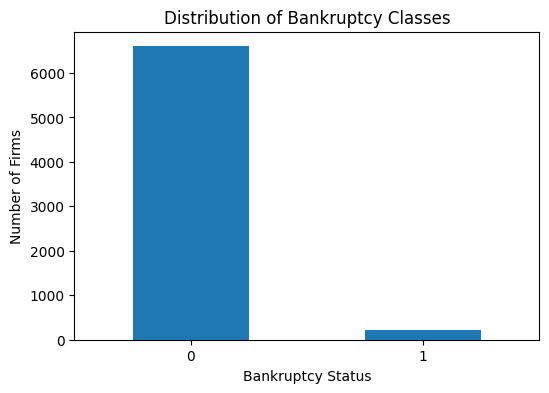

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

y.value_counts().plot(
    kind="bar"
)

plt.title("Distribution of Bankruptcy Classes")
plt.xlabel("Bankruptcy Status")
plt.ylabel("Number of Firms")

plt.xticks(rotation=0)

plt.show()

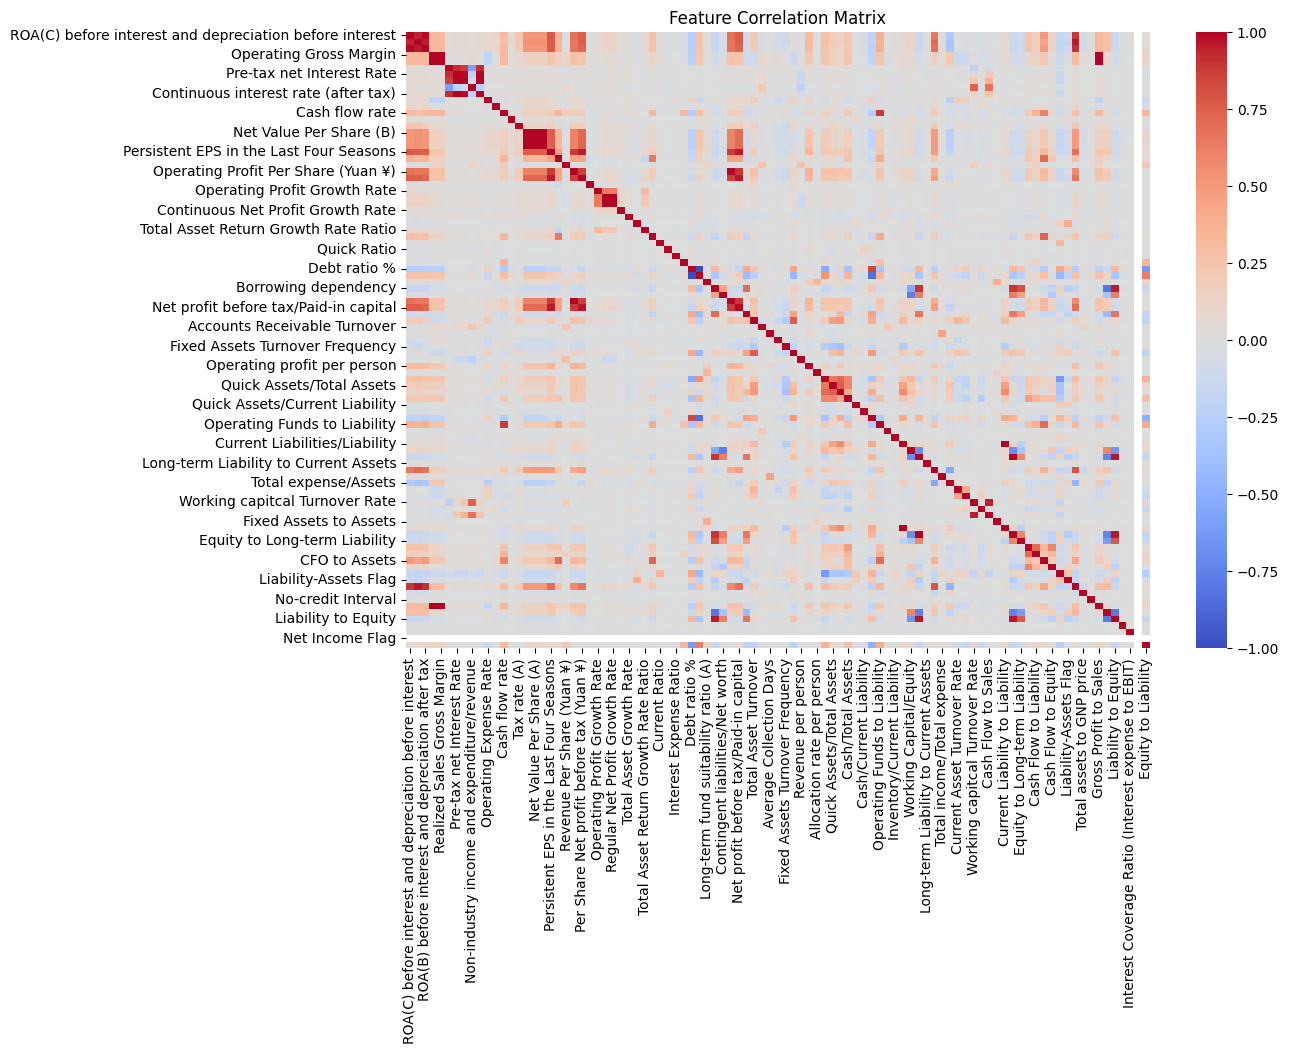

In [ ]:
# Feature correlation analysis

correlation_matrix = X.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

In [ ]:
# Find highly correlated feature pairs

high_corr = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i,j]) > 0.90:
            high_corr.append(
                (
                    correlation_matrix.columns[i],
                    correlation_matrix.columns[j],
                    correlation_matrix.iloc[i,j]
                )
            )

high_corr[:20]

[('ROA(A) before interest and % after tax',
  'ROA(C) before interest and depreciation before interest',
  np.float64(0.9401237079372291)),
 ('ROA(B) before interest and depreciation after tax',
  'ROA(C) before interest and depreciation before interest',
  np.float64(0.9868494970091584)),
 ('ROA(B) before interest and depreciation after tax',
  'ROA(A) before interest and % after tax',
  np.float64(0.9557406252875469)),
 ('Realized Sales Gross Margin',
  'Operating Gross Margin',
  np.float64(0.999518278122951)),
 ('Pre-tax net Interest Rate',
  'Operating Profit Rate',
  np.float64(0.9164477799917717)),
 ('After-tax net Interest Rate',
  'Pre-tax net Interest Rate',
  np.float64(0.9863790242151972)),
 ('Continuous interest rate (after tax)',
  'Operating Profit Rate',
  np.float64(0.9155437835954521)),
 ('Continuous interest rate (after tax)',
  'Pre-tax net Interest Rate',
  np.float64(0.9936165192552645)),
 ('Continuous interest rate (after tax)',
  'After-tax net Interest Rate',
 

In [ ]:
print("Number of highly correlated pairs:", len(high_corr))

Number of highly correlated pairs: 28


In [ ]:
# Remove highly correlated features

import numpy as np

corr_matrix = X.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.90)
]

print("Highly correlated features to remove:")
print(high_corr_features)

print("\nNumber of features removed:", len(high_corr_features))

Highly correlated features to remove:
['ROA(A) before interest and % after tax', 'ROA(B) before interest and depreciation after tax', 'Realized Sales Gross Margin', 'Pre-tax net Interest Rate', 'After-tax net Interest Rate', 'Continuous interest rate (after tax)', 'Net Value Per Share (A)', 'Net Value Per Share (C)', 'Per Share Net profit before tax (Yuan ¥)', 'Regular Net Profit Growth Rate', 'Net worth/Assets', 'Operating profit/Paid-in capital', 'Net profit before tax/Paid-in capital', 'Cash Flow to Sales', 'Current Liability to Liability', 'Current Liability to Equity', 'Net Income to Total Assets', 'Gross Profit to Sales', 'Liability to Equity']

Number of features removed: 19


In [ ]:
# Remove redundant features

X_reduced = X.drop(
    columns=high_corr_features
)

print("Original feature count:", X.shape[1])
print("Reduced feature count:", X_reduced.shape[1])

Original feature count: 95
Reduced feature count: 76


In [ ]:
X = X_reduced

print("Final feature matrix shape:")
print(X.shape)

Final feature matrix shape:
(6819, 76)


In [ ]:
from sklearn.preprocessing import StandardScaler

print("Scaler imported successfully")

Scaler imported successfully


In [ ]:
# Check available variables

%whos

Variable             Type              Data/Info
------------------------------------------------
StandardScaler       type              <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                    DataFrame               ROA(C) before inter<...>n[6819 rows x 76 columns]
X_reduced            DataFrame               ROA(C) before inter<...>n[6819 rows x 76 columns]
corr_matrix          DataFrame                                  <...>n\n[95 rows x 95 columns]
correlation_matrix   DataFrame                                  <...>n\n[95 rows x 95 columns]
df                   DataFrame               Bankrupt?  ROA(C) b<...>n[6819 rows x 96 columns]
high_corr            list              n=28
high_corr_features   list              n=19
i                    int               94
j                    int               93
np                   module            <module 'numpy' from '/us<...>kages/numpy/__init__.py'>
pd                   module            <module 'pandas' from '/u<

In [ ]:
from sklearn.model_selection import train_test_split

# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5455, 76)
Testing features: (1364, 76)
Training target: (5455,)
Testing target: (1364,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully")

Feature scaling completed successfully


In [ ]:
# Convert scaled arrays back to DataFrames

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)


print("Scaled training data:")
display(X_train_scaled.head())

Scaled training data:


,ROA(C) before interest and depreciation before interest,Operating Gross Margin,Operating Profit Rate,Non-industry income and expenditure/revenue,Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),...,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Total assets to GNP price,No-credit Interval,Net Income to Stockholder's Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,-0.176677,-0.542117,0.014704,-0.007591,1.489010,-0.748887,-0.065632,-0.151822,0.578043,0.348356,...,-0.137548,-0.190312,-0.030289,-0.04968,-0.013322,0.019121,-0.047674,-0.002594,0.0,0.475372
1,0.496220,-0.496455,0.017875,-0.013713,0.478365,-0.748887,-0.131227,-0.151822,0.998953,0.189136,...,0.019307,-0.191546,-0.030289,-0.04968,0.039302,0.259424,-0.045491,0.009096,0.0,-0.509747
2,0.363741,-0.060126,0.023791,-0.005259,1.752522,-0.205997,0.195128,-0.151822,0.861056,-0.068585,...,0.224626,-0.497354,-0.030289,-0.04968,0.072530,0.142392,-0.048977,-0.009972,0.0,0.253378
3,-0.575729,-0.726880,0.013707,-0.013214,0.341959,-0.748887,-0.238211,-0.151822,1.615517,-0.223757,...,0.444912,-0.014590,-0.030289,-0.04968,0.064900,-0.018003,0.001739,0.149999,0.0,-0.541738
4,-1.870631,3.328187,-0.215758,0.051511,-0.612884,-0.748887,-1.927154,-0.151822,-0.820418,-0.893022,...,-0.222198,-0.920690,-0.030289,-0.04968,0.034003,-0.215186,-0.048990,-0.010049,0.0,3.803505


In [ ]:
# Create processed output files

X_train_scaled.to_csv(
    "X_train_scaled.csv",
    index=False
)

X_test_scaled.to_csv(
    "X_test_scaled.csv",
    index=False
)

y_train.to_csv(
    "y_train.csv",
    index=False
)

y_test.to_csv(
    "y_test.csv",
    index=False
)


print("ML-ready datasets saved successfully")

ML-ready datasets saved successfully


In [ ]:
import os

print(os.listdir())

['.config', 'X_train_scaled.csv', 'X_test_scaled.csv', 'y_test.csv', 'y_train.csv', 'sample_data']


In [ ]:
from google.colab import files

files.download("X_train_scaled.csv")
files.download("X_test_scaled.csv")
files.download("y_train.csv")
files.download("y_test.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>